LAB 1: Perceptron
AND Gate | Weights: [0.2 0.1] | Bias: -0.20
  Accuracy=1.00  Precision=1.00  Recall=1.00
  Decision Boundary: 0.20*x1 + 0.10*x2 + -0.20 = 0


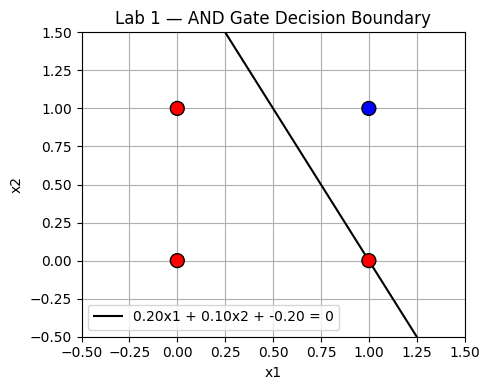


XOR Gate (expected to fail) | Accuracy=0.50
  XOR is not linearly separable — Perceptron cannot converge.



In [2]:
"""
=============================================================
Deep Learning Lab Series — LAB 1
Course: Deep Learning (22AIE304) | Batch: 2024-2028
NAME: PREM SANTH C K
ROLL NUMBER: CH.SC.U4AIE24056
=============================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def train_perceptron(X, y, lr=0.1, epochs=10):
    """Train a single-layer Perceptron using the Heaviside step function."""
    weights = np.zeros(X.shape[1])
    bias = 0

    for epoch in range(epochs):
        for i in range(len(X)):
            # 1. Calculate Linear Combination
            linear_output = np.dot(X[i], weights) + bias

            # 2. Apply Activation Function (Heaviside Step)
            y_pred = 1 if linear_output >= 0 else 0

            # 3. Compute Update (Error * Learning Rate)
            update = lr * (y[i] - y_pred)

            # 4. Update Weights and Bias
            weights += update * X[i]
            bias    += update

    return weights, bias


def predict_perceptron(X, weights, bias):
    linear_output = np.dot(X, weights) + bias
    return np.where(linear_output >= 0, 1, 0)


def evaluate_perceptron(X, y, weights, bias):
    preds = predict_perceptron(X, weights, bias)
    acc = np.mean(preds == y)
    tp = np.sum((preds == 1) & (y == 1))
    fp = np.sum((preds == 1) & (y == 0))
    fn = np.sum((preds == 0) & (y == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return acc, precision, recall


def plot_decision_boundary_perceptron(X, y, weights, bias, title="Perceptron Decision Boundary"):
    fig, ax = plt.subplots(figsize=(5, 4))
    x_vals = np.linspace(-0.5, 1.5, 200)
    if weights[1] != 0:
        y_vals = -(weights[0] * x_vals + bias) / weights[1]
        ax.plot(x_vals, y_vals, 'k-', label=f"{weights[0]:.2f}x1 + {weights[1]:.2f}x2 + {bias:.2f} = 0")
    colors = ['red' if label == 0 else 'blue' for label in y]
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=100, edgecolors='k', zorder=5)
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_title(title); ax.legend(); ax.grid(True)
    plt.tight_layout()
    plt.show() # Display in Colab


if __name__ == "__main__":
    print("=" * 60)
    print("LAB 1: Perceptron")
    print("=" * 60)

    # AND gate
    X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
    y_and = np.array([0, 0, 0, 1])
    w, b = train_perceptron(X_and, y_and, lr=0.1, epochs=10)
    acc, prec, rec = evaluate_perceptron(X_and, y_and, w, b)
    print(f"AND Gate | Weights: {w} | Bias: {b:.2f}")
    print(f"  Accuracy={acc:.2f}  Precision={prec:.2f}  Recall={rec:.2f}")
    print(f"  Decision Boundary: {w[0]:.2f}*x1 + {w[1]:.2f}*x2 + {b:.2f} = 0")
    plot_decision_boundary_perceptron(X_and, y_and, w, b, "Lab 1 — AND Gate Decision Boundary")

    # XOR gate (will NOT converge — Perceptron Convergence Theorem)
    X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
    y_xor = np.array([0, 1, 1, 0])
    w_xor, b_xor = train_perceptron(X_xor, y_xor, lr=0.1, epochs=100)
    acc_xor, _, _ = evaluate_perceptron(X_xor, y_xor, w_xor, b_xor)
    print(f"\nXOR Gate (expected to fail) | Accuracy={acc_xor:.2f}")
    print("  XOR is not linearly separable — Perceptron cannot converge.\n")